In [2]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import researchpy as rp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
import torch.nn.functional as F
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [93]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]
    df = pd.DataFrame([s[col_name][col_index] for s in d])
    result = []

    # Loop over the DataFrame in chunks of 750 columns
    for i in range(0, df.shape[1], chunk_size):
        # Sum the columns in the current chunk
        summed_chunk = df.iloc[:, i:i+chunk_size].sum(axis=1)
        # Add the summed result to the list
        result.append(summed_chunk)

    # Combine the results into a single DataFrame
    summed_df = pd.DataFrame(result).transpose()
    
    summed_df['method'] = method

    return summed_df

sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

/tmp/ipykernel_325718/2001807858.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  b = sns.barplot(data=data_mnist, x='method', y=0, estimator=np.median, ci=68)


[73884.5, 83098.5, 72564.0, 88784.0, 77533.5, 40858.5]


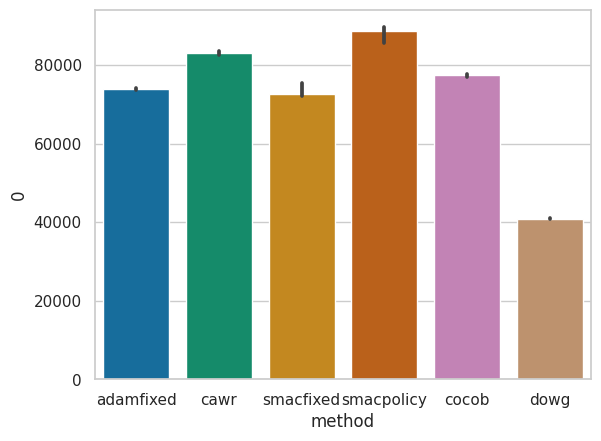

In [83]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacfixed')
cawr_ta_mnist = toChunkedDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 750, "cawr")
smacpolicy_ta_mnist = toDataFrame('./results_cluster/results/smacpolicy_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacpolicy')
dowg_ta_mnist = toDataFrame('./results_cluster/results/DoWG_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'dowg')
cdowg_ta_mnist = toDataFrame('./results_cluster/results/CDoWG_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cdowg')
data_mnist = pd.concat([adamfixed_ta_mnist, cawr_ta_mnist, smacfixed_ta_mnist, smacpolicy_ta_mnist, cocob_ta_mnist, dowg_ta_mnist])
b = sns.barplot(data=data_mnist, x='method', y=0, estimator=np.median, ci=68)
medians = [p.get_height() for p in b.patches]
print(medians)
# print(rp.summary_cont(adamfixed_ta_mnist[0]))
# print(rp.summary_cont(cawr_ta_mnist[0]))
# print(rp.summary_cont(smacfixed_ta_mnist[0]))
# print(rp.summary_cont(smacpolicy_ta_mnist[0]))
# print(rp.summary_cont(cocob_ta_mnist[0]))
# print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))

/tmp/ipykernel_325718/3955390642.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  b = sns.barplot(data=data_fmnist, x='method', y=0, estimator=np.median, ci=68)


[74623.5, 108413.0, 73160.5, 93047.0, 77955.5, 32890.0]


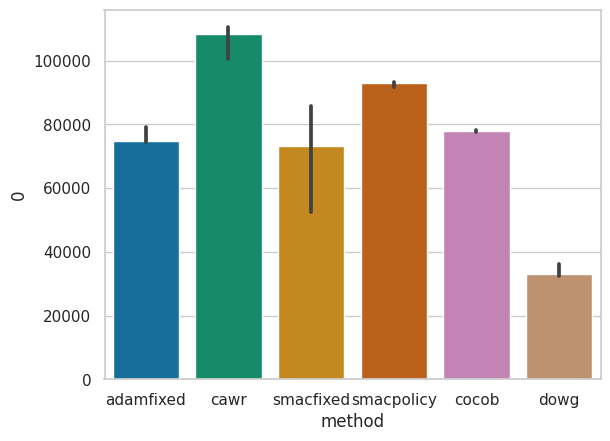

In [82]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacfixed')
cawr_ta_fmnist = toChunkedDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 750, "cawr")
smacpolicy_ta_fmnist = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacpolicy')
dowg_ta_fmnist = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'dowg')
data_fmnist = pd.concat([adamfixed_ta_fmnist, cawr_ta_fmnist, smacfixed_ta_fmnist, smacpolicy_ta_fmnist, cocob_ta_fmnist, dowg_ta_fmnist])
b = sns.barplot(data=data_fmnist, x='method', y=0, estimator=np.median, ci=68)
medians = [p.get_height() for p in b.patches]
print(medians)
# print(rp.summary_cont(adamfixed_ta_mnist[0]))
# print(rp.summary_cont(cawr_ta_mnist[0]))
# print(rp.summary_cont(smacfixed_ta_mnist[0]))
# print(rp.summary_cont(smacpolicy_ta_mnist[0]))
# print(rp.summary_cont(cocob_ta_mnist[0]))
# print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))

/tmp/ipykernel_325718/3627699959.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  b = sns.barplot(data=data_cifar10, x='method', y=0, estimator=np.median, ci=68)


[177213.0, 217261.5, 46462.5, 150199.0, 153791.0, 157725.5]


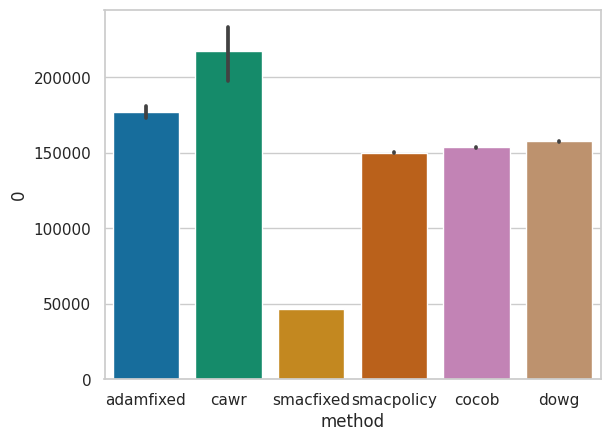

In [81]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'adamfixed')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacfixed')
cawr_ta_cifar10 = toChunkedDataFrame('./results_cluster/results/CAWR_cifar10_30/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 750, "cawr")
smacpolicy_ta_cifar10 = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacpolicy')
dowg_ta_cifar10 = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'dowg')
data_cifar10 = pd.concat([adamfixed_ta_cifar10, cawr_ta_cifar10, smacfixed_ta_cifar10, smacpolicy_ta_cifar10, cocob_ta_cifar10, dowg_ta_cifar10])
b = sns.barplot(data=data_cifar10, x='method', y=0, estimator=np.median, ci=68)
medians = [p.get_height() for p in b.patches]
print(medians)
# print(rp.summary_cont(adamfixed_ta_mnist[0]))
# print(rp.summary_cont(cawr_ta_mnist[0]))
# print(rp.summary_cont(smacfixed_ta_mnist[0]))
# print(rp.summary_cont(smacpolicy_ta_mnist[0]))
# print(rp.summary_cont(cocob_ta_mnist[0]))
# print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))

/tmp/ipykernel_325718/4014818590.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  b = sns.barplot(data=data_cifar100, x='method', y=0, estimator=np.median, ci=68)


[65170.0, 118268.5, 124999.0, 156049.0, 76079.5, 57382.5]


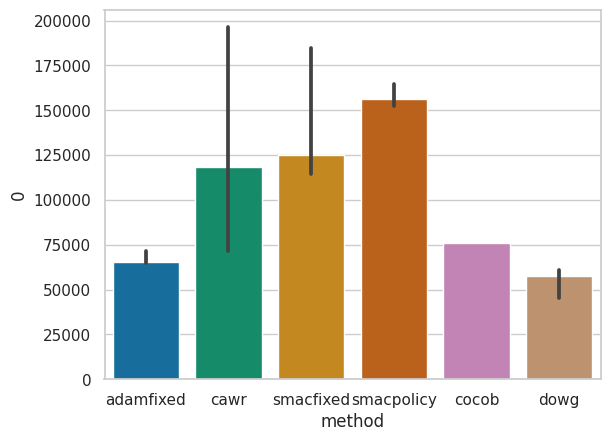

In [80]:
cocob_ta_cifar100 = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'cocob')
adamfixed_ta_cifar100 = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'adamfixed')
smacfixed_ta_cifar100 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacfixed')
cawr_ta_cifar100 = toChunkedDataFrame('./results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 750, "cawr")
smacpolicy_ta_cifar100 = toDataFrame('./results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'smacpolicy')
dowg_ta_cifar100 = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'step_times', 2, 'dowg')
data_cifar100 = pd.concat([adamfixed_ta_cifar100, cawr_ta_cifar100, smacfixed_ta_cifar100, smacpolicy_ta_cifar100, cocob_ta_cifar100, dowg_ta_cifar100])
b = sns.barplot(data=data_cifar100, x='method', y=0, estimator=np.median, ci=68)
medians = [p.get_height() for p in b.patches]
print(medians)
# print(rp.summary_cont(adamfixed_ta_mnist[0]))
# print(rp.summary_cont(cawr_ta_mnist[0]))
# print(rp.summary_cont(smacfixed_ta_mnist[0]))
# print(rp.summary_cont(smacpolicy_ta_mnist[0]))
# print(rp.summary_cont(cocob_ta_mnist[0]))
# print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))

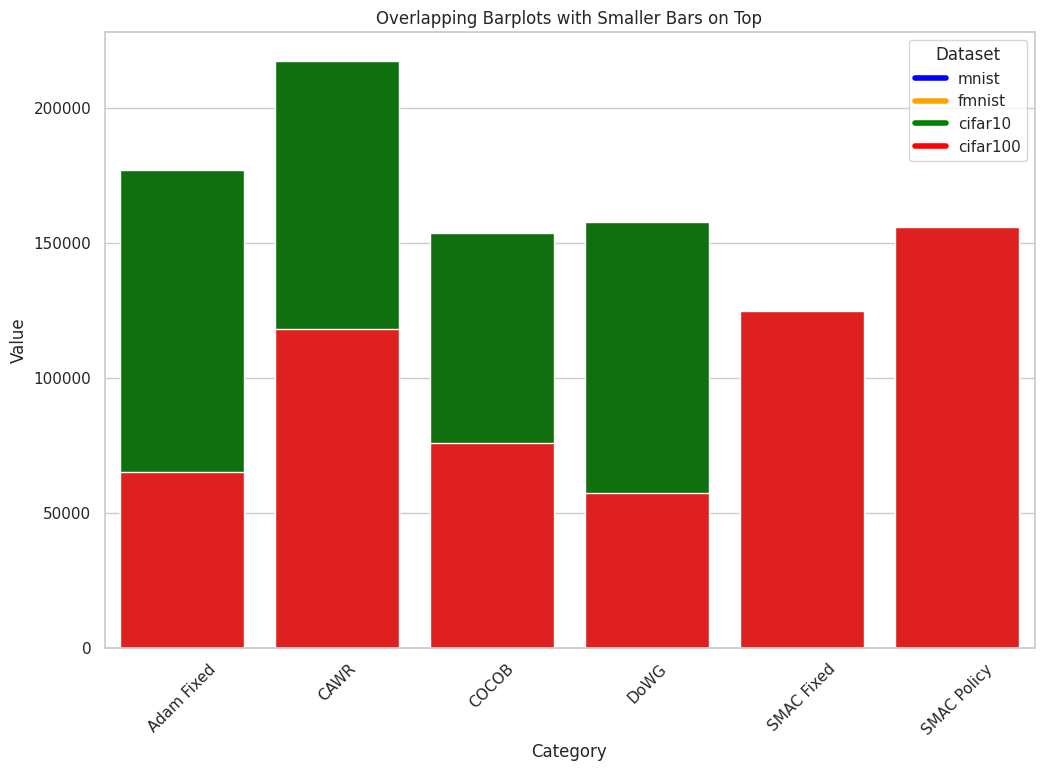

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Given Data
data = pd.DataFrame({
    'Category': ['Adam Fixed', 'CAWR', 'SMAC Fixed', 'SMAC Policy', "COCOB", "DoWG"],
    'mnist': [73884.5, 83098.5, 72564.0, 88784.0, 77533.5, 40858.5],
    'fmnist': [74623.5, 108413.0, 73160.5, 93047.0, 77955.5, 32890.0],
    'cifar10': [177213.0, 217261.5, 46462.5, 150199.0, 153791.0, 157725.5],
    'cifar100': [65170.0, 118268.5, 124999.0, 156049.0, 76079.5, 57382.5]
})

# Melt the dataframe to long format
melted_data = pd.melt(data, id_vars='Category', var_name='Dataset', value_name='Value')

# Sort within each category by value, so smaller bars are plotted last
sorted_data = melted_data.sort_values(by=['Category', 'Value'], ascending=[True, False])

# Define the color palette
colors = {
    'mnist': 'blue',
    'fmnist': 'orange',
    'cifar10': 'green',
    'cifar100': 'red'
}

# Initialize the plot
plt.figure(figsize=(12, 8))

# Plot each dataset in a loop, ensuring smaller bars are plotted last
for dataset in ['mnist', 'fmnist', 'cifar10', 'cifar100']:
    sns.barplot(
        data=sorted_data[sorted_data['Dataset'] == dataset],
        x='Category',
        y='Value',
        color=colors[dataset],
        dodge=False
    )

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels and title
plt.ylabel('Value')
plt.title('Overlapping Barplots with Smaller Bars on Top')

# Display the legend
plt.legend(handles=[plt.Line2D([0], [0], color=colors[ds], lw=4) for ds in colors], labels=colors.keys(), title='Dataset')

plt.show()


In [19]:
import json

# Opening JSON file
f = open('results_cluster/results/smacpolicy_cifar10_1/smac3_output/6c4a05b0072ba1156e3b55cb5b61b515/1/runhistory.json')

# returns JSON object as 
# a dictionary
data = json.load(f)

# Iterating through the json
# list
maxI = data['data'][0]
for i in data['data']:
    if i[4] < maxI[4]:
        maxI = i

print(maxI)

print(data['configs']['{}'.format(maxI[0])])

# Closing file
f.close()

[237, None, 1791095845, None, -0.08104356568132003, 22648.893430233, 1, 1723755257.0392883, 1723777905.9342346, {}]
{'x0': 0.001529885706290909, 'x1': 0.002794182531201569, 'x10': 0.00304654136353216, 'x11': 0.004892258077537285, 'x12': 0.002378748332705129, 'x13': 0.0024472413321039543, 'x14': 0.0021153548079027346, 'x15': 0.0017059255443778332, 'x16': 0.0024692999194684474, 'x17': 0.004513075879525776, 'x18': 0.003643061512008205, 'x19': 0.002181398056240455, 'x2': 0.004804014239871173, 'x20': 3.4681871298153854e-05, 'x21': 0.0012177597943052799, 'x22': 0.003987806919179982, 'x23': 0.0038958154856253723, 'x24': 0.003982681457233959, 'x25': 0.004135128759578226, 'x26': 0.004198129582126079, 'x27': 0.0018751477867694603, 'x28': 0.003783942958199853, 'x29': 0.0010626152504533786, 'x3': 0.00479072738415169, 'x4': 0.004882868183840954, 'x5': 0.004766662664630416, 'x6': 0.0015985545015721704, 'x7': 0.003961006145149245, 'x8': 0.00136052314675375, 'x9': 0.0024146632656460772}
